이 노트북에서는 외부 소스의 데이터를 로드 및 저장하는 레시피를 이용할 수 있습니다.

In [3]:
# ✅ 1. 구글 드라이브 연결
from google.colab import drive
drive.mount('/content/drive')

# ✅ 2. 라이브러리 import
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# ✅ 3. 데이터 경로 설정 (여기만 너 경로 맞추면 됨 ⭐)
data_dir = "/content/drive/MyDrive/오소프 데이터셋/dataset"

# ✅ 4. 기본 설정
img_height = 224
img_width = 224
batch_size = 32

# ✅ 5. 데이터 로드 (자동으로 train/val 나눔)
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

class_names = train_ds.class_names
print("클래스:", class_names)

# ✅ 6. 성능 향상 옵션 (속도 + 성능)
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

# ✅ 7. 데이터 증강 (중요 ⭐)
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

# ✅ 8. MobileNetV2 전이학습 모델
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(img_height, img_width, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False  # 핵심 ⭐

# ✅ 9. 모델 구성
model = models.Sequential([
    data_augmentation,
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dense(len(class_names), activation='softmax')
])

# ✅ 10. 컴파일
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# ✅ 11. 학습
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

# ✅ 12. 모델 저장 (드라이브에 저장 ⭐)
model.save("/content/drive/MyDrive/garbage_classification_model_inception.h5")

print("✅ 모델 저장 완료!")

# ✅ 13. 학습 결과 그래프 (가산점용 ⭐)
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

plt.plot(acc, label='train_acc')
plt.plot(val_acc, label='val_acc')
plt.legend()
plt.title("Accuracy")
plt.show()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/오소프 데이터셋/dataset'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 1576 files belonging to 3 classes.
Using 1261 files for training.
Found 1576 files belonging to 3 classes.
Using 315 files for validation.
클래스 순서: ['can', 'paper', 'plastic']
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 502s 12s/step - accuracy: 0.6923 - loss: 0.6877 - val_accuracy: 0.7016 - val_loss: 0.6689
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 111s 3s/step - accuracy: 0.8049 - loss: 0.4579 - val_accuracy: 0.6667 - val_loss: 0.7199
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 138s 3s/step - accuracy: 0.8652 - loss: 0.3483 - val_accuracy: 0.7460 - val_loss: 0.5876
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 120s 3s/step - accuracy: 0.8779 - loss: 0.3143 - val_accuracy: 0.7365 - val_loss: 0.6173
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 141s 3s/step - accuracy: 0.8977 - loss: 0.2635 - val_accuracy: 0.7492 - val_loss: 0.6424
Epoch

✅ 모델 저장 완료!


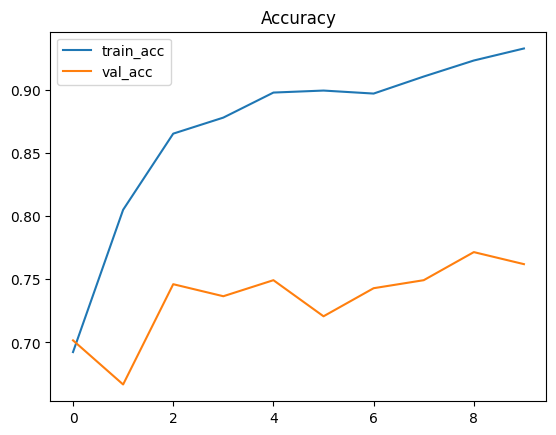

In [9]:
# ✅ 1. 구글 드라이브 연결
from google.colab import drive
drive.mount('/content/drive')

# ✅ 2. 라이브러리
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# ✅ 3. 데이터 경로
data_dir = "/content/drive/MyDrive/오소프 데이터셋/dataset"

# ✅ 4. 설정
img_height = 224
img_width = 224
batch_size = 32

# ✅ 5. 데이터 로드
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

# ✅ 클래스 순서 확인 (중요 ⭐)
class_names = train_ds.class_names
print("클래스 순서:", class_names)

# 👉 반드시 이렇게 나와야 함:
# ['can', 'paper', 'plastic']

# ✅ 성능 최적화
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

# ✅ 데이터 증강
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

# ✅ 모델 (MobileNetV2)
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

# ✅ 모델 구성
model = models.Sequential([
    data_augmentation,
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dense(len(class_names), activation='softmax')
])

# ✅ 컴파일
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# ✅ 학습
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

# ✅ 모델 저장
model.save("/content/drive/MyDrive/garbage_classification_model_inception.h5")

print("✅ 모델 저장 완료!")

# ✅ 그래프
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.legend()
plt.title("Accuracy")
plt.show()


In [8]:
import os
os.listdir('/content/drive/MyDrive')


['21221 이현지 (1).gdoc',
 '21221 이현지.gdoc',
 '21221 이현지 나노공학과.gdoc',
 'www.homeppt.gdoc',
 '0908 한영고 파이썬.ipynb',
 '기하 보고서.hwp',
 '기하 모둠수행평가 2학년.pptx',
 '셀룰로오스를 이용한 친환경 Bio-Chemical 하우스 제작.gdoc',
 '입시지원_수시_이현지.cell',
 '생활기록부 정리표_이현지.cell',
 '수특영단어.pdf',
 "귀하와 '559_37a09f7b738522'을(를) 공유합니다..pdf",
 '2023수능대비 확률과 통계 빠른답.pdf',
 '~ R&E신청서.hwp',
 '미래직진-대학생활설계 2416136 의류학과 이현지.hwp',
 'Google 앱에서 저장된 이미지',
 '세븐틴 팔로우콘 직찍',
 '오소프 데이터셋']

# 로컬 파일 시스템

## 로컬 파일 시스템의 파일 업로드

<code>files.upload</code>는 업로드된 파일의 사전을 반환합니다.
사전은 업로드된 파일 이름에 따라 키가 지정되며, 값은 업로드된 데이터를 표시합니다.

In [ ]:
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))

## 로컬 파일 시스템으로 파일 다운로드

<code>files.download</code>는 파일의 브라우저 다운로드를 로컬 컴퓨터로 호출합니다.


In [ ]:
from google.colab import files

with open('example.txt', 'w') as f:
  f.write('some content')

files.download('example.txt')

# Google Drive

다음과 같은 여러 가지 방법으로 드라이브에 있는 파일에 액세스할 수 있습니다.
- 런타임 가상 머신에 Google Drive 마운트
- <a href="https://docs.iterative.ai/PyDrive2/">PyDrive2</a>와 같은 API 래퍼 사용
- <a href="https://developers.google.com/drive/v3/web/about-sdk">네이티브 REST API</a> 사용



각각의 예시는 다음과 같습니다.

## 로컬에 Google Drive 마운트하기

아래의 예시에서는 승인 코드를 사용해 런타임에 Google Drive를 마운트하는 방법 및 이 드라이브에서 파일을 쓰고 읽는 방법을 보여 줍니다. 이 예시를 실행하면 <a href="https://drive.google.com/">https://drive.google.com/</a>에 새 파일&#40;<code>foo.txt</code>&#41;이 표시됩니다.

이 방법으로는 파일을 읽고, 쓰고 이동하는 작업만 가능하므로 프로그래매틱 방식으로 공유 설정이나 기타 메타데이터를 수정하려면 아래의 다른 옵션 중 하나를 사용하세요.

<strong>참고:</strong> 파일 브라우저의 '드라이브 마운트' 버튼을 사용할 때 현재 사용자만 수정한 메모장에 대해서는 인증 코드는 필요하지 않습니다.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Go to this URL in a browser: https://accounts.google.com/o/oauth2/auth?client_id=947318989803-6bn6qk8qdgf4n4g3pfee6491hc0brc4i.apps.googleusercontent.com&redirect_uri=urn%3Aietf%3Awg%3Aoauth%3A2.0%3Aoob&scope=email%20https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fdocs.test%20https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fdrive%20https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fdrive.photos.readonly%20https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fpeopleapi.readonly&response_type=code
Enter your authorization code:
··········
Mounted at /content/drive


In [ ]:
with open('/content/drive/My Drive/foo.txt', 'w') as f:
  f.write('Hello Google Drive!')
!cat /content/drive/My\ Drive/foo.txt

Hello Google Drive!

In [ ]:
drive.flush_and_unmount()
print('All changes made in this colab session should now be visible in Drive.')

All changes made in this colab session should now be visible in Drive.


## PyDrive2

아래 예시에서는 PyDrive2를 사용하여 인증하고 파일을 업로드/다운로드하는 방법을 설명합니다. <a href="https://docs.iterative.ai/PyDrive2/">PyDrive2 문서</a>에서 더 많은 예시를 살펴보세요.

In [ ]:
from pydrive2.auth import GoogleAuth
from pydrive2.drive import GoogleDrive
from google.colab import auth
from oauth2client.client import GoogleCredentials

PyDrive2 클라이언트를 인증하고 만듭니다.


In [ ]:
auth.authenticate_user()
gauth = GoogleAuth()
gauth.credentials = GoogleCredentials.get_application_default()
drive = GoogleDrive(gauth)

텍스트 파일을 만들고 업로드합니다.


In [ ]:
uploaded = drive.CreateFile({'title': 'Sample upload.txt'})
uploaded.SetContentString('Sample upload file content')
uploaded.Upload()
print('Uploaded file with ID {}'.format(uploaded.get('id')))

Uploaded file with ID 14vDAdqp7BSCQnoougmgylBexIr2AQx2T


ID별로 파일을 로드하고 파일 내용을 출력합니다.


In [ ]:
downloaded = drive.CreateFile({'id': uploaded.get('id')})
print('Downloaded content "{}"'.format(downloaded.GetContentString()))

Downloaded content "Sample upload file content"


## Drive REST API

Drive API를 사용하려면 인증한 다음 API 클라이언트를 구성해야 합니다.


In [ ]:
from google.colab import auth
auth.authenticate_user()
from googleapiclient.discovery import build
drive_service = build('drive', 'v3')

이 클라이언트를 사용하면 <a href="https://developers.google.com/drive/v3/reference/">Google Drive API 참조</a>에 있는 모든 기능을 사용할 수 있습니다. 기능의 예시는 다음과 같습니다.


### Python 데이터로 새 드라이브 파일 만들기

먼저 업로드할 로컬 파일을 만듭니다.

In [ ]:
with open('/tmp/to_upload.txt', 'w') as f:
  f.write('my sample file')

print('/tmp/to_upload.txt contains:')
!cat /tmp/to_upload.txt

/tmp/to_upload.txt contains:
my sample file

<a href="https://developers.google.com/drive/v3/reference/files/create"><code>files.create</code></a> 방식을 사용해 업로드합니다. 업로드 파일에 관한 추가 정보는 <a href="https://developers.google.com/drive/v3/web/manage-uploads">개발자 도움말</a>에서 확인할 수 있습니다.

In [ ]:
from googleapiclient.http import MediaFileUpload

file_metadata = {
  'name': 'Sample file',
  'mimeType': 'text/plain'
}
media = MediaFileUpload('/tmp/to_upload.txt',
                        mimetype='text/plain',
                        resumable=True)
created = drive_service.files().create(body=file_metadata,
                                       media_body=media,
                                       fields='id').execute()
print('File ID: {}'.format(created.get('id')))

File ID: 1Cw9CqiyU6zbXFD9ViPZu_3yX-sYF4W17


위의 셀을 실행하면 <a href="https://drive.google.com/">https://drive.google.com/</a>에 'Sample file'이라는 새 파일이 표시됩니다.

### 드라이브 파일 데이터를 Python으로 다운로드

위에서 업로드한 파일을 다운로드합니다.

In [ ]:
file_id = created.get('id')

import io
from googleapiclient.http import MediaIoBaseDownload

request = drive_service.files().get_media(fileId=file_id)
downloaded = io.BytesIO()
downloader = MediaIoBaseDownload(downloaded, request)
done = False
while done is False:
  # _ is a placeholder for a progress object that we ignore.
  # (Our file is small, so we skip reporting progress.)
  _, done = downloader.next_chunk()

downloaded.seek(0)
print('Downloaded file contents are: {}'.format(downloaded.read()))

Downloaded file contents are: b'my sample file'


다른 파일을 다운로드하려면 위의 <code>file&#95;id</code>를 파일의 ID로 설정하세요. ID의 형식은 '1uBtlaggVyWshwcyP6kEI-y&#95;W3P8D26sz'와 같습니다.

# Google Sheets


## Google Sheets Workspace 확장 프로그램

Workspace 확장 프로그램인 <a href="https://workspace.google.com/u/0/marketplace/app/sheets_to_colab/945625412720">Sheets to Colab</a>을 통해 Google Sheets의 데이터를 Sheets UI에서 Colab으로 직접 가져올 수 있습니다. 자세히 알아보려면 Workspace 확장 프로그램 Sheets to Colab로 연결되는 링크를 참고하세요.

## gspread를 사용하여 Google Sheets와 상호작용하기

오픈소스 <a href="https://github.com/burnash/gspread"><code>gspread</code></a> 라이브러리를 사용하여 Google Sheets와 상호작용할 수도 있습니다. 아래 코드는 <code>gspread</code>를 설정하고 인증하는 방법을 보여줍니다.

In [ ]:
from google.colab import auth
auth.authenticate_user()

import gspread
from google.auth import default
creds, _ = default()

gc = gspread.authorize(creds)

다음은 몇 가지 <code>gspread</code> 예시입니다. 추가 예시는 <a href="https://github.com/burnash/gspread#more-examples"><code>gspread</code> GitHub 페이지</a>에서 확인할 수 있습니다.

### Python 데이터로 새 시트 만들기

In [ ]:
sh = gc.create('My cool spreadsheet')

위의 셀을 실행하면 <a href="https://sheets.google.com/">https://sheets.google.com</a>에 'My cool spreadsheet'라는 새 스프레드시트가 표시됩니다.

새 시트를 열고 몇 가지 데이터를 무작위로 추가합니다.

In [ ]:
worksheet = gc.open('My cool spreadsheet').sheet1

cell_list = worksheet.range('A1:C2')

import random
for cell in cell_list:
  cell.value = random.randint(1, 10)

worksheet.update_cells(cell_list)

{'spreadsheetId': '1dsQeN0YzXuM387l_CuyEbsYzL2ew9TJFzR-E-RQnwxs',
 'updatedCells': 6,
 'updatedColumns': 3,
 'updatedRange': 'Sheet1!A1:C2',
 'updatedRows': 2}

### 시트의 데이터를 Pandas DataFrame으로 Python에 다운로드

위에서 삽입한 무작위 데이터를 다시 읽고 결과를 <a href="https://pandas.pydata.org/pandas-docs/stable/generated/pandas.DataFrame.html">Pandas DataFrame</a>으로 변환합니다.

In [ ]:
worksheet = gc.open('My cool spreadsheet').sheet1

# get_all_values gives a list of rows.
rows = worksheet.get_all_values()
print(rows)

import pandas as pd
pd.DataFrame.from_records(rows)

[['6', '3', '4'], ['7', '2', '1']]


,0,1,2
0,6,3,4
1,7,2,1


# InteractiveSheet

이제 <code>InteractiveSheet</code> 라이브러리를 사용하여 실시간 Google Sheets를 Colab에 삽입할 수 있습니다. 즉, Google Sheets에서 데이터를 생성 및 수정하고 Colab의 Pandas DataFrame을 사용하여 노트북에 이를 원활하게 통합할 수 있습니다.

In [ ]:
from google.colab import sheets

# Create a new interactive sheet and add data to it.
sheet = sheets.InteractiveSheet()

In [ ]:
# Get a Pandas DataFrame from the selected worksheet
df = sheet.as_df()

In [ ]:
import pandas as pd
import numpy as np

df = pd.DataFrame(np.random.randn(10, 4), columns=list('ABCD'))

# Create a new sheet and include the column names as the first row.
sheet = sheets.InteractiveSheet(df=df, title='foo', include_column_headers=True)

In [ ]:
# Push data from Colab to the selected worksheet
df2 = pd.DataFrame(np.random.randn(10, 4), columns=list('ABCD'))
sheet.update(df=df)

In [ ]:
# Display the sheet in the output of the current cell
sheet.display()

# Google Cloud Storage&#40;GCS&#41;

GCS와 함께 Colaboratory를 사용하려면 <a href="https://cloud.google.com/storage/docs/projects">Google Cloud 프로젝트</a>를 만들거나 기존 프로젝트를 사용해야 합니다.

아래에서 프로젝트 ID를 지정하세요.

In [ ]:
project_id = 'Your_project_ID_here'

GCS의 파일은 <a href="https://cloud.google.com/storage/docs/buckets">버킷</a>에 보관됩니다.

버킷에는 전역 고유 이름이 필요하므로 여기에서 하나 생성하겠습니다.

In [ ]:
import uuid
bucket_name = 'colab-sample-bucket-' + str(uuid.uuid1())

GCS에 액세스하려면 인증이 필요합니다.

In [ ]:
from google.colab import auth
auth.authenticate_user()

GCS는 <code>gsutil</code> 명령줄 유틸리티 또는 네이티브 Python API를 통해 액세스할 수 있습니다.

## `gsutil`

먼저 <code>gcloud</code>를 사용해 위에서 지정한 프로젝트를 사용할 수 있도록 <code>gsutil</code>을 설정합니다.

In [ ]:
!gcloud config set project {project_id}

Updated property [core/project].


업로드할 로컬 파일을 만듭니다.

In [ ]:
with open('/tmp/to_upload.txt', 'w') as f:
  f.write('my sample file')

print('/tmp/to_upload.txt contains:')
!cat /tmp/to_upload.txt

/tmp/to_upload.txt contains:
my sample file

파일을 업로드할 버킷을 만듭니다&#40;<a href="https://cloud.google.com/storage/docs/gsutil/commands/mb">도움말</a>&#41;.

In [ ]:
!gsutil mb gs://{bucket_name}

Creating gs://colab-sample-bucket-44971372-baaf-11e7-ae30-0242ac110002/...


파일을 새 버킷으로 복사합니다&#40;<a href="https://cloud.google.com/storage/docs/gsutil/commands/cp">도움말</a>&#41;.

In [ ]:
!gsutil cp /tmp/to_upload.txt gs://{bucket_name}/

Copying file:///tmp/to_upload.txt [Content-Type=text/plain]...
/ [1 files][   14.0 B/   14.0 B]                                                
Operation completed over 1 objects/14.0 B.                                       


모든 항목이 제대로 작동하도록 새롭게 복사한 파일의 내용을 덤프합니다&#40;<a href="https://cloud.google.com/storage/docs/gsutil/commands/cat">도움말</a>&#41;.


In [ ]:
!gsutil cat gs://{bucket_name}/to_upload.txt

my sample file

In [ ]:
# @markdown 업로드가 완료되면 프로젝트의 Cloud Console Storage 브라우저에 데이터가 표시됩니다.
print('https://console.cloud.google.com/storage/browser?project=' + project_id)

https://console.cloud.google.com/storage/browser?project=Your_project_ID_here


마지막으로 위 예시에 방금 업로드한 파일을 다운로드해 보겠습니다. <code>gsutil cp</code> 명령어에서 순서를 반대로 바꾸기만 하면 됩니다.

In [ ]:
!gsutil cp gs://{bucket_name}/to_upload.txt /tmp/gsutil_download.txt

# 전송이 제대로 작동하는지 확인하기 위해 결과를 출력합니다.
!cat /tmp/gsutil_download.txt

Copying gs://colab-sample-bucket483f20dc-baaf-11e7-ae30-0242ac110002/to_upload.txt...
/ [1 files][   14.0 B/   14.0 B]                                                
Operation completed over 1 objects/14.0 B.                                       
my sample file

## Python API

다음 스니펫은 API의 추가적인 사용 사례를 보여 주는 <a href="https://github.com/GoogleCloudPlatform/storage-file-transfer-json-python/blob/master/chunked_transfer.py">대규모 예시</a>를 기반으로 합니다.

먼저 서비스 클라이언트를 만듭니다.

In [ ]:
from googleapiclient.discovery import build
gcs_service = build('storage', 'v1')

업로드할 로컬 파일을 만듭니다.

In [ ]:
with open('/tmp/to_upload.txt', 'w') as f:
  f.write('my sample file')

print('/tmp/to_upload.txt contains:')
!cat /tmp/to_upload.txt

/tmp/to_upload.txt contains:
my sample file

위에서 지정된 프로젝트에 버킷을 만듭니다.

In [ ]:
# 위의 gsutil 예시와 다른 전역 고유 버킷 이름을 사용하세요.
import uuid
bucket_name = 'colab-sample-bucket-' + str(uuid.uuid1())

body = {
  'name': bucket_name,
  # For a full list of locations, see:
  # https://cloud.google.com/storage/docs/bucket-locations
  'location': 'us',
}
gcs_service.buckets().insert(project=project_id, body=body).execute()
print('Done')

Done


새롭게 만든 버킷에 파일을 업로드합니다.

In [ ]:
from googleapiclient.http import MediaFileUpload

media = MediaFileUpload('/tmp/to_upload.txt',
                        mimetype='text/plain',
                        resumable=True)

request = gcs_service.objects().insert(bucket=bucket_name,
                                       name='to_upload.txt',
                                       media_body=media)

response = None
while response is None:
  # _ is a placeholder for a progress object that we ignore.
  # (Our file is small, so we skip reporting progress.)
  _, response = request.next_chunk()

print('Upload complete')

Upload complete


In [ ]:
# @markdown 업로드가 완료되면 프로젝트의 Cloud Console Storage 브라우저에 데이터가 표시됩니다.
print('https://console.cloud.google.com/storage/browser?project=' + project_id)

https://console.cloud.google.com/storage/browser?project=Your_project_ID_here


방금 업로드한 파일을 다운로드합니다.

In [ ]:
from apiclient.http import MediaIoBaseDownload

with open('/tmp/downloaded_from_gcs.txt', 'wb') as f:
  request = gcs_service.objects().get_media(bucket=bucket_name,
                                            object='to_upload.txt')
  media = MediaIoBaseDownload(f, request)

  done = False
  while not done:
    # _ is a placeholder for a progress object that we ignore.
    # (Our file is small, so we skip reporting progress.)
    _, done = media.next_chunk()

print('Download complete')

Download complete


다운로드된 파일을 검사합니다.


In [ ]:
!cat /tmp/downloaded_from_gcs.txt

my sample file